<a href="https://colab.research.google.com/github/CarlKo-DLSU/PowerpuffCarl-MP1/blob/main/MP_Problem1_PowerpuffCarl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MP1 - Problem 1 | Powerpuff Carl


This notebook demonstrates the full state evolution of the quantum expression

    |ψ⟩ = HZH|0⟩

The notebook breaks the process into several major tasks:

1. Constructing the quantum circuits that correspond to each prefix of HZH.
   We do not apply HZH as a single circuit. Instead we construct **four**
   separate circuits:

    - Identity circuit: |0⟩
    - Apply H:          H|0⟩
    - Apply ZH:         ZH|0⟩
    - Apply HZH:        HZH|0⟩ (final)

   This step-by-step approach allows us to clearly see how each gate changes
   the quantum state.

2. Converting each circuit into a statevector.
   This gives a numerical “proof” of the state after each transformation.
   The statevector encodes exact complex amplitudes for |0⟩ and |1⟩.

3. Visualizing each state on the Bloch sphere.
   All single-qubit pure states lie on the Bloch sphere. This makes it possible
   to interpret phase flips (Z gates), rotations (H gates), and overall quantum
   orientation geometrically.

4. Rendering a GIF animation that shows the evolution.
   For each step we create a combined visualization:

    - Bloch sphere (left)
    - Circuit diagram (right)
    - Statevector text (below)

These are assembled into a GIF that plays the entire evolution smoothly.

# Install required quantum and visualization libraries

We install all third-party Python packages required for:

- Building quantum circuits (qiskit)
- Simulating quantum states at the amplitude level (qiskit-aer)
- Displaying Bloch spheres and drawing circuits (qiskit.visualization)
- Converting LaTeX circuit labels to ASCII/Unicode (pylatexenc)
- Creating plots (matplotlib)
- Creating animated GIFs (imageio + pillow)
- Handling numeric operations for statevectors (numpy)

These installations only need to run once per notebook session. They install
tools for:

- Quantum computation
- High-quality visualization
- Image rendering and animation

Qiskit is particularly important because it provides:

- QuantumCircuit   → gate-by-gate circuit construction
- Statevector      → exact wavefunction simulation
- plot_bloch_vector → geometric visualization

In [ ]:
!pip install qiskit
!pip install qiskit-aer
!pip install pylatexenc
!pip install matplotlib
!pip install imageio
!pip install pillow
!pip install numpy

# Import core scientific and visualization tools

Here we import all core computational and visualization tools.

- numpy:
    Used for complex vector math, coordinate extraction, and array operations.
- matplotlib.pyplot:
    Used to plot the Bloch sphere alongside circuit diagrams.
- PIL (Pillow):
    Enables image processing, combining PNG figures into frames, and
    ultimately producing the GIF animation.
- qiskit.QuantumCircuit:
    Lets us explicitly construct the quantum circuit corresponding to
    each prefix of H Z H.
- qiskit.quantum_info.Statevector:
    Allows the simulation of quantum states without measurement.
    This produces exact amplitudes of |0⟩ and |1⟩.
- pylatexenc:
    Converting names like "|ψ⟩" into plain unicode strings prevents display
    issues when printing state labels.
- IPython.display:
    Used to display the final GIF inline inside the notebook.

These imports set the stage for:
  - mathematical computation
  - circuit simulation
  - data visualization
  - image processing

In [ ]:
import io
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from qiskit import QuantumCircuit
from qiskit.visualization import plot_bloch_vector
from qiskit.quantum_info import Statevector
from pylatexenc.latex2text import LatexNodes2Text

# For inline display in Jupyter
from IPython.display import display, Image as IPyImage

# Convert a statevector into its Bloch sphere coordinates

The Bloch sphere is the standard geometric representation of a single qubit.
Every pure qubit state |ψ⟩ can be expressed as:

    |ψ⟩ = cos(θ/2)|0⟩ + e^{iφ} sin(θ/2)|1⟩

This corresponds to coordinates on a unit sphere:

    x = sin(θ)cos(φ)
    y = sin(θ)sin(φ)
    z = cos(θ)

However, the amplitudes a, b in the computational basis give a more direct
formula:

    x = 2 Re(a* b)
    y = 2 Im(a* b)
    z = |a|² − |b|²

Where:
    a = amplitude of |0⟩
    b = amplitude of |1⟩

This helper function takes a Statevector, extracts its amplitudes, and computes
the geometric position (x, y, z) on the Bloch sphere.

We use these coordinates to create visual snapshots of the qubit’s “direction”
after each gate, allowing us to trace how the state moves around the sphere.
Used to visualize the qubit’s orientation after each gate in the circuit.

In [ ]:
# Helper: convert Statevector to Bloch vector (x,y,z)
def statevector_to_blochvec(sv: Statevector):
    a, b = sv.data[0], sv.data[1]
    x = 2 * np.real(np.conj(a) * b)
    y = 2 * np.imag(np.conj(a) * b)
    z = np.abs(a) ** 2 - np.abs(b) ** 2
    return [x, y, z]

# Convert a Qiskit circuit diagram into a PIL image

QuantumCircuit.draw('mpl') internally uses Matplotlib to draw the circuit and
returns a Matplotlib figure. However, to later combine the circuit image with:

  - Bloch sphere (figure)
  - Text displaying the statevector
  - The final GIF

we require a raster image (PNG), not a Matplotlib object.

This helper function:

1. Renders the circuit using Matplotlib.
2. Saves the figure into an in-memory PNG buffer (BytesIO) so we avoid writing
   to disk.
3. Opens the PNG buffer using Pillow (PIL.Image) to convert it into a usable
   RGBA image.
4. Returns the PIL image for embedding.

This mechanism allows us to overlay or place circuit diagrams inside custom
composite visualizations that include Bloch spheres and text.

In [ ]:
# Helper: render a QuantumCircuit (mpl) to a PIL.Image
def circuit_to_pil(qc: QuantumCircuit, dpi=150):
    fig = qc.draw(output="mpl", style={"backgroundcolor":"white"})
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    img = Image.open(buf).convert("RGBA")
    buf.close()
    return img

# Build the sequence of circuits for HZH|0⟩

This section defines the four circuits we want to animate. Instead of applying
the entire sequence H Z H at once, we break it down into snapshots of the
intermediate states.

This gives us:

    qc0 → |0⟩
    qc1 → H|0⟩
    qc2 → ZH|0⟩
    qc3 → HZH|0⟩

Why separate circuits?

Because each circuit:
  - Represents the qubit BEFORE the next gate is applied
  - Helps visualize the state transition induced by a single gate
  - Allows us to animate the movement on the Bloch sphere step-by-step

For example:
  - H takes |0⟩ to |+⟩ (a 90° rotation around X-axis)
  - Z applies a phase flip, reflecting the state across the Z-axis
  - A final H brings the state back to |0⟩

This decomposition is essential for visualization-based understanding.

In [ ]:
# Build circuits
qc0 = QuantumCircuit(1)                                # |0>
qc1 = QuantumCircuit(1); qc1.h(0)                      # H|0>
qc2 = QuantumCircuit(1); qc2.h(0); qc2.z(0)            # ZH|0>
qc3 = QuantumCircuit(1); qc3.h(0); qc3.z(0); qc3.h(0)  # HZH|0>

circuits = [
    ("|0⟩ (initial)", qc0),
    ("H|0⟩", qc1),
    ("ZH|0⟩", qc2),
    ("HZH|0⟩ (final)", qc3)
]

# Compute statevectors for each circuit (the “proof”)

This loop performs the mathematical verification that each circuit performs
the correct transformation on the qubit.

We simulate each circuit’s full statevector, which returns the **exact** complex
amplitudes for |0⟩ and |1⟩ *before any measurement*.

For example:

    Statevector.from_instruction(qc1)

gives the amplitudes of H|0⟩, which are (1/√2, 1/√2).

This lets us explicitly prove:

    |0⟩ → |+⟩ → |+⟩ → |0⟩

We print each statevector with rounding for readability.
This printed output is the “proof” that matches the expected theoretical results.

The latex-to-text conversion allows labels like "|0⟩" to print properly.

In [ ]:
# Proof: compute and print statevectors
print("State evolution proof (statevectors):")
for label, qc in circuits:
    sv = Statevector.from_instruction(qc)
    pretty_label = LatexNodes2Text().latex_to_text(label)
    print(f"{pretty_label}: {np.round(sv.data, 6)}")

State evolution proof (statevectors):
|0⟩ (initial): [1.+0.j 0.+0.j]
H|0⟩: [0.707107+0.j 0.707107+0.j]
ZH|0⟩: [ 0.707107+0.j -0.707107+0.j]
HZH|0⟩ (final): [0.+0.j 1.+0.j]


# Create individual animation frames (Bloch + circuit)

To build the GIF animation, we need a visual frame for each circuit snapshot.
Each frame consists of:

- Left:  Bloch sphere showing the direction of the qubit state.
- Right: The quantum circuit diagram leading to that state.
- Bottom: The actual numeric statevector (complex amplitudes).

Process for each frame:

1. Compute the statevector.
2. Convert the statevector into Bloch sphere coordinates.
3. Draw that Bloch sphere using Matplotlib.
4. Render circuit diagram using the earlier "circuit_to_pil" helper.
5. Draw both images into a single figure canvas.
6. Add the statevector text to the figure using monospaced styling.
7. Save the combined figure to a PNG buffer.
8. Convert PNG buffer to a PIL image and append to the frames list.

At the end, `frames_pil` contains one image for each stage of the evolution.
These frames will later be assembled into a GIF.

In [ ]:
# Create PIL frames
frames_pil = []
for label, qc in circuits:
    sv = Statevector.from_instruction(qc)
    bloch = statevector_to_blochvec(sv)

    fig = plt.figure(figsize=(8, 4), constrained_layout=True)
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.2])

    ax0 = fig.add_subplot(gs[0], projection="3d")
    ax0.set_title(label, fontsize=12)
    plot_bloch_vector(bloch, ax=ax0)

    ax1 = fig.add_subplot(gs[1])
    ax1.axis("off")
    circ_img = circuit_to_pil(qc, dpi=200)
    circ_w, circ_h = circ_img.size
    max_w = 600
    if circ_w > max_w:
        circ_img = circ_img.resize((max_w, int(circ_h * max_w / circ_w)), Image.LANCZOS)
    ax1.imshow(circ_img)

    sv_text = np.array2string(np.round(sv.data, 6), separator=', ')
    fig.text(0.55, 0.06, "Statevector:\n" + sv_text, fontsize=9, family="monospace",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    pil_img = Image.open(buf).convert("RGBA")
    buf.close()
    frames_pil.append(pil_img)

# Standardize image sizes before making the GIF

GIF animation requires all frames to be the exact same width and height.
Because circuit diagrams vary slightly in size depending on their content,
our generated frames may differ in dimensions.

To fix this:
- Determine the maximum width and height among all frames.
- Create a blank white canvas of that size.
- Center each frame onto this canvas.

After this step, every frame has uniform dimensions, ensuring:
- smooth animation
- proper alignment
- predictable playback timing

We also convert RGBA → palette mode because GIFs use an indexed color table.

In [ ]:
# Normalize canvas size and center each frame
max_w = max(img.width for img in frames_pil)
max_h = max(img.height for img in frames_pil)
standardized = []
for img in frames_pil:
    canvas = Image.new("RGBA", (max_w, max_h), (255, 255, 255, 255))
    x = (max_w - img.width) // 2
    y = (max_h - img.height) // 2
    canvas.paste(img, (x, y), img)
    standardized.append(canvas.convert("P", palette=Image.ADAPTIVE))

# Build and display GIF animation

Finally, we assemble the standardized image frames into a GIF.

We write the GIF into an in-memory buffer instead of disk. This keeps the
notebook self-contained.

Parameters:
- duration = 1000 ms between frames
- loop = 0   → infinite looping
- disposal = 2 → allow frames to overwrite previous frames cleanly

We then display the GIF directly in the notebook using IPython.display.

Result:
    A smooth animation that visually narrates the evolution of |ψ⟩
    as it undergoes H, then Z, then H again.

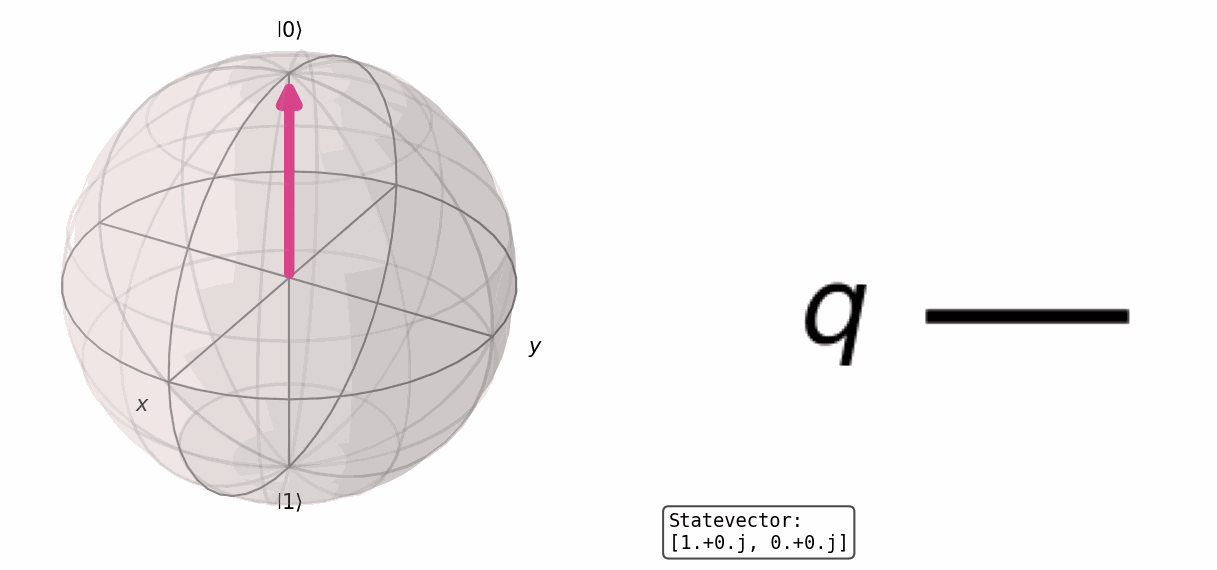

In [ ]:
# Save GIF into an in-memory buffer and display inline
gif_buf = io.BytesIO()
standardized[0].save(
    gif_buf,
    format="GIF",
    save_all=True,
    append_images=standardized[1:],
    duration=int(1 * 1000),
    loop=0,
    disposal=2,
)
gif_buf.seek(0)

# Display inline in the notebook
display(IPyImage(data=gif_buf.getvalue(), format='gif'))

# Results
Running the program will result in a looping GIF animation, showing the step-by-step evolution of the qubit state |ψ⟩ = HZH|0⟩ on the Bloch sphere, with corresponding circuit diagrams and statevectors.